# Imports

In [44]:
import pandas as pd
import numpy as np
import re
from collections import Counter
import matplotlib.pyplot as plt

In [46]:
papers = [
    {
        "paper_id": "P1",
        "title": "Expression of the PPM1F Gene Is Regulated by Stress and Associated With Anxiety and Depression",
        "year": 2017,
        "journal": "",
        "first_author": "",
        "institution": "",
        "country": "",
        "mental_condition": "Stress; Anxiety; Depression",
        "genes": "PPM1F",
        "mechanism": "Gene expression",
        "study_type": "Experimental",
        "abstract": "Background: Molecular mechanisms underlying psychological sequelae of exposure to stressful experiences, such as posttraumatic stress disorder (PTSD) and depression, are not well understood.Methods: Using convergent evidence from animal and human transcriptomic and genomic studies, we aimed to identify genetic mechanisms underlying depression and anxiety after traumatic experiences.Results: From a transcriptome-wide analysis in mice, we found the Ppm1f gene to be differentially expressed in the amygdala and medial prefrontal cortex (mPFC) a week after immobilization stress. Next, we found that PPM1F messenger RNA levels in human blood were downregulated in cases with symptoms of comorbid PTSD and depression and consistently in cases with anxiety symptoms in a separate human dataset. Furthermore, we showed that a genetic variant of PPM1F, rs17759843, was associated with comorbid PTSD and depression and with PPM1F expression in both human brain and blood. Given prior reported mechanistic links between PPM1F and CAMK2 (CAMKII), we examined blood messenger RNA level of CAMK2G in humans and found it to be lower in cases with comorbid PTSD and depression. We also found that PPM1F protein levels and colocalization with CAMK2G were altered in amygdala and mPFC of male mice. Additionally, we found that a systemic dose of corticosterone blocked the depressive-like phenotype elicited by stress in female mice. Lastly, corticosterone rescued the anxiety-like phenotype and messenger RNA levels of Ppm1f in amygdala and mPFC in male mice and in mPFC of female mice. Conclusions: Taken together, our data suggest a mechanistic pathway involving PPM1F and CAMK2G in stress- and trauma-related manifestation of anxiety and depression across species.Keywords: Anxiety; CAMK2; Depression; PPM1F; PTSD; Stress.",
        "notes": "Core dataset paper",
        "link": "https://pubmed.ncbi.nlm.nih.gov/29054677/"
    },
    {
        "paper_id": "P2",
        "title": "Epigenetic Changes of FKBP5 as a Link Connecting Genetic and Environmental Risk Factors with Structural and Functional Brain Changes in Major Depression",
        "year": 2018,
        "journal": "",
        "first_author": "",
        "institution": "",
        "country": "",
        "mental_condition": "Depression",
        "genes": "FKBP5",
        "mechanism": "DNA methylation; Epigenetics",
        "study_type": "Review",
        "abstract": "",
        "notes": "Important FKBP5 paper",
        "link": "https://pubmed.ncbi.nlm.nih.gov/29182159/"
    },
    {
        "paper_id": "P3",
        "title": "FKBP5-related stress and psychiatric disorder paper",
        "year": 2018,
        "journal": "",
        "first_author": "",
        "institution": "",
        "country": "",
        "mental_condition": "Stress; Psychiatric disorders",
        "genes": "FKBP5",
        "mechanism": "Gene regulation; Stress response",
        "study_type": "Review",
        "abstract": "The gene for the glucocorticoid receptor regulator FK506 binding protein 5 (FKBP5) plays a role for risk, response to treatment, and changes in brain areas in major depressive disorder (MDD). Chronic stress is associated with lower methylation of FKBP5. Our aim was to investigate whether methylation of FKBP5 reflected exposure to childhood adversity in MDD and controls and whether it was associated with structure and function of emotional processing regions. FKBP5 intron 7 GR response element region methylation and rs1360780 allelic status were assessed from whole blood in 56 MDD adults and 50 controls. Using magnetic resonance imaging, we assessed gray matter concentration of selected areas and their function during valence recognition of emotional images. Childhood adversity was investigated using the Childhood Trauma Questionnaire. In MDD patients carrying the high-risk T allele of rs1360780, lower methylation of FKBP5 was predicted by childhood adversity (F=4.95, p=0.04). In all participants, lower FKBP5 intron methylation levels were associated with reduced gray matter concentration in the inferior frontal orbital gyrus bilaterally (Wald chi-square=11.93, pFDR<0.01) and, in MDD, with its bilaterally higher activation during valence recognition (Wald chi-square=5.58, p=0.02). Activation of this region, regardless of side, was found to be lower in MDD compared to controls (Wald chi-square=3.88, p=0.049) and to be inversely correlated with depression severity (Wald chi-square=4.65, p=0.03). Our findings support the hypothesis that, in genetically predisposed individuals carrying a high-risk variant of the gene, childhood maltreatment might induce demethylation of FKBP5. This is in turn associated with structural and functional changes in the inferior frontal orbital gyrus, a relevant area for the clinical symptoms of MDD.",
        "notes": "Supporting FKBP5 paper",
        "link": "https://pubmed.ncbi.nlm.nih.gov/30172967/"
    },
    {
        "paper_id": "P4",
        "title": "Recent advances in FKBP5 and stress-related disorders",
        "year": 2023,
        "journal": "",
        "first_author": "",
        "institution": "",
        "country": "",
        "mental_condition": "Stress-related disorders",
        "genes": "FKBP5",
        "mechanism": "DNA methylation; Epigenetics; Stress response",
        "study_type": "Review",
        "abstract": "Different factors are essential in increasing the vulnerability to psychiatric disorders, such as genetics. Among these factors, early life stress (ELS), including sexual, physical, emotional abuse, and emotional and physical neglect, enhances the odds of having menial conditions throughout life. Exhaustive research has shown that ELS leads to physiological changes, such as alteration in the HPA axis. During the most critical development period (childhood and adolescence), these changes increase the risk of having child-onset psychiatric disorders. Furthermore, research has suggested a relationship between early life stress and depression, particularly more prolonged episodes of depression with treatment-resistant outcomes. Molecular studies indicate that, in general, the hereditary character of psychiatric disorders is polygenic, multifactorial and highly complex, with innumerable low-effect genetic variants interacting with each other. However, whether there are independent effects among subtypes of ELS remains unclear. This article provides an overview of the interplay of epigenetics, the HPA axis, early life stress and the development of depression. Advances in our knowledge of epigenetics in the context of early life stress and depression provide a new understanding of the genetic influence on psychopathology. Furthermore, they could lead to identifying new targets for clinical intervention.Keywords: Childhood trauma; Cortisol; Depression; Early life stress; Epigenetic; Genetic; HPA axis; Stress.",
        "notes": "Recent FKBP5 paper",
        "link": "https://pubmed.ncbi.nlm.nih.gov/36863799/"
    },
    {
        "paper_id": "P5",
        "title": "BDNF methylation in PTSD patients",
        "year": 2025,
        "journal": "",
        "first_author": "",
        "institution": "",
        "country": "",
        "mental_condition": "PTSD",
        "genes": "BDNF",
        "mechanism": "DNA methylation; Epigenetics",
        "study_type": "Meta-analysis",
        "abstract": "Objective: Police, firefighters, dispatchers, and emergency medical technicians-collectively known as first responders-are a unique population frequently exposed to chronic, traumatic incidents. This exposure results in a high prevalence of PTSD, depression, and anxiety, posing a substantial public health concern. Genetic predispositions and epigenetic modifications that regulate gene expression are significant contributors to trauma-related pathologies. This systematic review aims to summarize current data on epigenetic and gene expression changes in first responders related to three post-trauma pathologies: PTSD, depression, and anxiety. We also explore genetic pathways across these disorders to identify potential commonalities and therapeutic targets.Methods: Following PRISMA guidelines, databases were searched from July to October 2023, yielding 1103 studies, 12 of which met the inclusion criteria (total N = 6943).Results: Of the included studies, 11 examined PTSD, consistently implicating stress-response genes, such as those in the hypothalamic-pituitary-adrenal axis (e.g., FKBP5, NR3C1), and genes related to inflammation and immune responses. Three studies focused on depression-related genetic biomarkers but reported no significant genome-wide methylation differences between responders with current versus no major depressive disorder (MDD). No studies addressed epigenetic or gene expression changes linked to anxiety.Conclusion: This review identified novel genes and pathways related to trauma as potential targets for future research and pharmacological therapy. It also highlights a significant gap in the literature, emphasizing the need for broader research to investigate the genetic underpinnings of trauma exposure in first responders, aiming to identify relevant pathways and therapeutic targets.Keywords: Anxiety; Depression; Epigenesis; First responders; Genes; PTSD; Trauma.",
        "notes": "BDNF and PTSD",
        "link": "https://pubmed.ncbi.nlm.nih.gov/39892213/"
    },
    {
        "paper_id": "P6",
        "title": "Gene expression and methylation signatures of MAN2C1 are associated with PTSD",
        "year": 2011,
        "journal": "",
        "first_author": "",
        "institution": "",
        "country": "",
        "mental_condition": "PTSD",
        "genes": "MAN2C1",
        "mechanism": "Gene expression; DNA methylation",
        "study_type": "Experimental",
        "abstract": "As potential regulators of DNA accessibility and activity, epigenetic modiﬁcations offer a mechanism by which theenvironment can moderate the effects of genes. To date, however, there have been relatively few studies assessing epigeneticmodiﬁcations associated with post-traumatic stress disorder (PTSD). Here we investigate PTSD-associated methylation differ-ences in 33 genes previously shown to differ in whole blood-derived gene expression levels between those with vs. without thedisorder. Drawing on DNA samples similarly obtained from whole blood in 100 individuals, 23 with and 77 without lifetimePTSD, we used methylation microarray data to assess whether these 33 candidate genes showed epigenetic signatures indicativeof increased risk for, or resilience to, PTSD. Logistic regression analyses were performed to assess the main and interactingeffects of candidate genes’ methylation values and number of potentially traumatic events (PTEs), adjusting for age and othercovariates. Results revealed that only one candidate gene – MAN2C1 – showed a signiﬁcant methylation x PTE interaction, suchthat those with both higher MAN2C1 methylation and greater exposure to PTEs showed a marked increase in risk of lifetimePTSD (OR 4.35, 95% CI: 1.07, 17.77, p = 0.04). These results indicate that MAN2C1 methylation levels modify cumulativetraumatic burden on risk of PTSD, and suggest that both gene expression and epigenetic changes at speciﬁc loci are associatedwith this disorder.Keywords: Epigenetics, psychiatric epidemiology, trauma, interaction, genomics",
        "notes": "PTSD gene-specific paper",
        "link": "https://onlinelibrary.wiley.com/doi/epdf/10.3233/DMA-2011-0750"
    },
    {
        "paper_id": "P7",
        "title": "Maternal depression, anxiety and genome-wide DNA methylation in newborns",
        "year": 2014,
        "journal": "",
        "first_author": "",
        "institution": "",
        "country": "",
        "mental_condition": "Depression; Anxiety",
        "genes": "Genome-wide",
        "mechanism": "DNA methylation; Epigenetics",
        "study_type": "Experimental",
        "abstract": "Despite the high prevalence of depression, anxiety, and use of antidepressant medications during pregnancy, there is much uncertainty around the impact of high levels of distress or antidepressant medications on the developing fetus. These intrauterine exposures may lead to epigenetic alterations to the DNA during this vulnerable time of fetal development, which may have important lifetime health consequences. In this study we investigated patterns of genome-wide DNA methylation using the Illumina Infinium Human Methylation450 BeadChip in the umbilical cord blood of neonates exposed to non-medicated maternal depression or anxiety (n = 13), or selective serotonin reuptake inhibitors (SSRIs) during pregnancy (n = 22), relative to unexposed neonates (n = 23). We identified 42 CpG sites with significantly different DNA methylation levels in neonates exposed to non-medicated depression or anxiety relative to controls. CpG site methylation was not significantly different in neonates exposed to SSRIs relative to the controls, after adjusting for multiple comparisons. In neonates exposed either to non-medicated maternal depression or SSRIs, the vast majority of CpG sites displayed lower DNA methylation relative to the controls, but differences were very small. A gene ontology analysis suggests significant clustering of the top genes associated with non-medicated maternal depression/anxiety, related to regulation of transcription, translation, and cell division processes (e.g., negative regulation of translation in response to oxidative stress, regulation of mRNA export from the nucleus, regulation of stem cell division). While the functional consequences of these findings are yet to be determined, these small DNA methylation differences may suggest a possible role for epigenetic processes in the development of neonates exposed to non-medicated maternal depression/anxiety.",
        "notes": "Prenatal mental health and methylation",
        "link": "https://www.tandfonline.com/doi/full/10.4161/epi.28853"
    },
        {
        "paper_id": "P8",
        "title": "Genome-wide association study of major anxiety disorders in 122,341 European-ancestry cases identifies 58 loci and highlights GABAergic signaling",
        "year": 2026,
        "journal": "",
        "first_author": "",
        "institution": "",
        "country": "",
        "mental_condition": "Depression; Anxiety",
        "genes": "Genome-wide",
        "mechanism": "DNA methylation; Epigenetics",
        "study_type": "Experimental",
        "abstract": "The major anxiety disorders (ANX; including generalized anxiety disorder, panic disorder and phobias) are highly prevalent, often onset early and cause substantial global disability. Although distinct in their clinical presentations, they probably represent differential expressions of a dysregulated threat–response system. Here, we present a genome-wide association meta-analysis comprising 122,341 European ancestry ANX cases and 729,881 controls. We identified 58 independent genome-wide significant risk variants and 66 genes with robust biological support. In an independent sample of 1,175,012 self-report ANX cases and 1,956,379 controls, 51 out of the 58 associations replicated. As predicted by twin studies, we found substantial genetic correlation between ANX and depression, neuroticism and other internalizing phenotypes. Follow-up analyses demonstrated enrichment in all major brain regions and highlighted GABAergic signaling as one potential mechanism implicated in ANX genetic risk. These results advance our understanding of the genetic architecture of ANX and prioritize genes for functional follow-up studies.",
        "notes": "Prenatal mental health and methylation",
        "link": "https://www.nature.com/articles/s41588-025-02485-8"
    },
]

In [47]:
df = pd.DataFrame(papers)
df

,paper_id,title,year,journal,first_author,institution,country,mental_condition,genes,mechanism,study_type,abstract,notes,link
0,P1,Expression of the PPM1F Gene Is Regulated by S...,2017,,,,,Stress; Anxiety; Depression,PPM1F,Gene expression,Experimental,Background: Molecular mechanisms underlying ps...,Core dataset paper,https://pubmed.ncbi.nlm.nih.gov/29054677/
1,P2,Epigenetic Changes of FKBP5 as a Link Connecti...,2018,,,,,Depression,FKBP5,DNA methylation; Epigenetics,Review,,Important FKBP5 paper,https://pubmed.ncbi.nlm.nih.gov/29182159/
2,P3,FKBP5-related stress and psychiatric disorder ...,2018,,,,,Stress; Psychiatric disorders,FKBP5,Gene regulation; Stress response,Review,The gene for the glucocorticoid receptor regul...,Supporting FKBP5 paper,https://pubmed.ncbi.nlm.nih.gov/30172967/
3,P4,Recent advances in FKBP5 and stress-related di...,2023,,,,,Stress-related disorders,FKBP5,DNA methylation; Epigenetics; Stress response,Review,Different factors are essential in increasing ...,Recent FKBP5 paper,https://pubmed.ncbi.nlm.nih.gov/36863799/
4,P5,BDNF methylation in PTSD patients,2025,,,,,PTSD,BDNF,DNA methylation; Epigenetics,Meta-analysis,"Objective: Police, firefighters, dispatchers, ...",BDNF and PTSD,https://pubmed.ncbi.nlm.nih.gov/39892213/
5,P6,Gene expression and methylation signatures of ...,2011,,,,,PTSD,MAN2C1,Gene expression; DNA methylation,Experimental,As potential regulators of DNA accessibility a...,PTSD gene-specific paper,https://onlinelibrary.wiley.com/doi/epdf/10.32...
6,P7,"Maternal depression, anxiety and genome-wide D...",2014,,,,,Depression; Anxiety,Genome-wide,DNA methylation; Epigenetics,Experimental,"Despite the high prevalence of depression, anx...",Prenatal mental health and methylation,https://www.tandfonline.com/doi/full/10.4161/e...


In [48]:
df.to_csv("psygene_papers_raw.csv", index=False)
print("Saved: psygene_papers_raw.csv")

Saved: psygene_papers_raw.csv


In [49]:
df = pd.read_csv("psygene_papers_raw.csv")

text_cols = [
    "title", "journal", "first_author", "institution", "country",
    "mental_condition", "genes", "mechanism", "study_type", "abstract", "notes", "link"
]

for col in text_cols:
    df[col] = df[col].fillna("").astype(str).str.strip()

df["year"] = pd.to_numeric(df["year"], errors="coerce")
df["paper_id"] = df["paper_id"].astype(str).str.strip()

df = df.drop_duplicates(subset=["link"]).reset_index(drop=True)

df.to_csv("psygene_papers_clean.csv", index=False)
print("Saved: psygene_papers_clean.csv")
df.head()

Saved: psygene_papers_clean.csv


,paper_id,title,year,journal,first_author,institution,country,mental_condition,genes,mechanism,study_type,abstract,notes,link
0,P1,Expression of the PPM1F Gene Is Regulated by S...,2017,,,,,Stress; Anxiety; Depression,PPM1F,Gene expression,Experimental,Background: Molecular mechanisms underlying ps...,Core dataset paper,https://pubmed.ncbi.nlm.nih.gov/29054677/
1,P2,Epigenetic Changes of FKBP5 as a Link Connecti...,2018,,,,,Depression,FKBP5,DNA methylation; Epigenetics,Review,,Important FKBP5 paper,https://pubmed.ncbi.nlm.nih.gov/29182159/
2,P3,FKBP5-related stress and psychiatric disorder ...,2018,,,,,Stress; Psychiatric disorders,FKBP5,Gene regulation; Stress response,Review,The gene for the glucocorticoid receptor regul...,Supporting FKBP5 paper,https://pubmed.ncbi.nlm.nih.gov/30172967/
3,P4,Recent advances in FKBP5 and stress-related di...,2023,,,,,Stress-related disorders,FKBP5,DNA methylation; Epigenetics; Stress response,Review,Different factors are essential in increasing ...,Recent FKBP5 paper,https://pubmed.ncbi.nlm.nih.gov/36863799/
4,P5,BDNF methylation in PTSD patients,2025,,,,,PTSD,BDNF,DNA methylation; Epigenetics,Meta-analysis,"Objective: Police, firefighters, dispatchers, ...",BDNF and PTSD,https://pubmed.ncbi.nlm.nih.gov/39892213/


In [50]:
missing_summary = df.isna().sum().sort_values(ascending=False)
missing_summary

paper_id            0
title               0
year                0
journal             0
first_author        0
institution         0
country             0
mental_condition    0
genes               0
mechanism           0
study_type          0
abstract            0
notes               0
link                0
dtype: int64

In [51]:
# Also check empty strings in important text columns
for col in ["journal", "first_author", "institution", "country", "abstract"]:
    empty_count = (df[col].astype(str).str.strip() == "").sum()
    print(f"{col}: {empty_count} empty values")

journal: 7 empty values
first_author: 7 empty values
institution: 7 empty values
country: 7 empty values
abstract: 1 empty values


In [52]:
# Example: manually edit one row if needed
df.loc[df["paper_id"] == "P1", "journal"] = "Molecular Psychiatry"
df.loc[df["paper_id"] == "P1", "first_author"] = ""
df.loc[df["paper_id"] == "P1", "country"] = ""

df.to_csv("psygene_papers_clean.csv", index=False)

In [53]:
print("Number of papers:", len(df))
print("\nStudy types:")
print(df["study_type"].value_counts())

print("\nMechanisms:")
print(df["mechanism"].value_counts())

print("\nMental conditions:")
print(df["mental_condition"].value_counts())

Number of papers: 7

Study types:
study_type
Experimental     3
Review           3
Meta-analysis    1
Name: count, dtype: int64

Mechanisms:
mechanism
DNA methylation; Epigenetics                     3
Gene expression                                  1
Gene regulation; Stress response                 1
DNA methylation; Epigenetics; Stress response    1
Gene expression; DNA methylation                 1
Name: count, dtype: int64

Mental conditions:
mental_condition
PTSD                             2
Stress; Anxiety; Depression      1
Depression                       1
Stress; Psychiatric disorders    1
Stress-related disorders         1
Depression; Anxiety              1
Name: count, dtype: int64


In [54]:
papers_per_year = df["year"].value_counts().sort_index()
papers_per_year

year
2011    1
2014    1
2017    1
2018    2
2023    1
2025    1
Name: count, dtype: int64

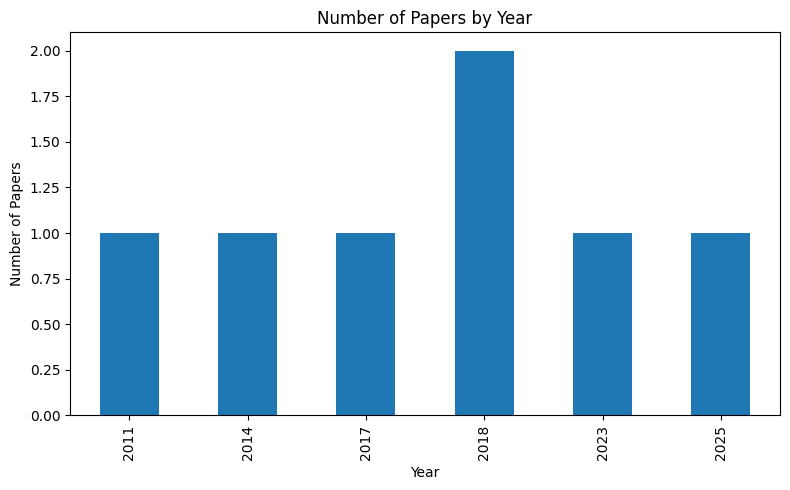

In [55]:
plt.figure(figsize=(8, 5))
papers_per_year.plot(kind="bar")
plt.title("Number of Papers by Year")
plt.xlabel("Year")
plt.ylabel("Number of Papers")
plt.tight_layout()
plt.show()

In [56]:
study_type_counts = df["study_type"].value_counts()
study_type_counts

study_type
Experimental     3
Review           3
Meta-analysis    1
Name: count, dtype: int64

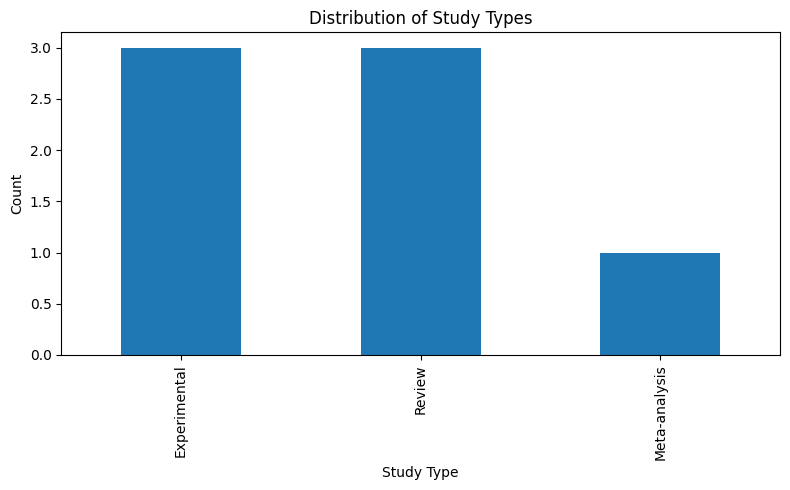

In [57]:
plt.figure(figsize=(8, 5))
study_type_counts.plot(kind="bar")
plt.title("Distribution of Study Types")
plt.xlabel("Study Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [58]:
condition_counter = Counter()

for value in df["mental_condition"]:
    items = [x.strip() for x in str(value).split(";") if x.strip()]
    condition_counter.update(items)

condition_df = pd.DataFrame(condition_counter.items(), columns=["mental_condition", "count"])
condition_df = condition_df.sort_values("count", ascending=False).reset_index(drop=True)
condition_df

,mental_condition,count
0,Depression,3
1,Stress,2
2,Anxiety,2
3,PTSD,2
4,Psychiatric disorders,1
5,Stress-related disorders,1


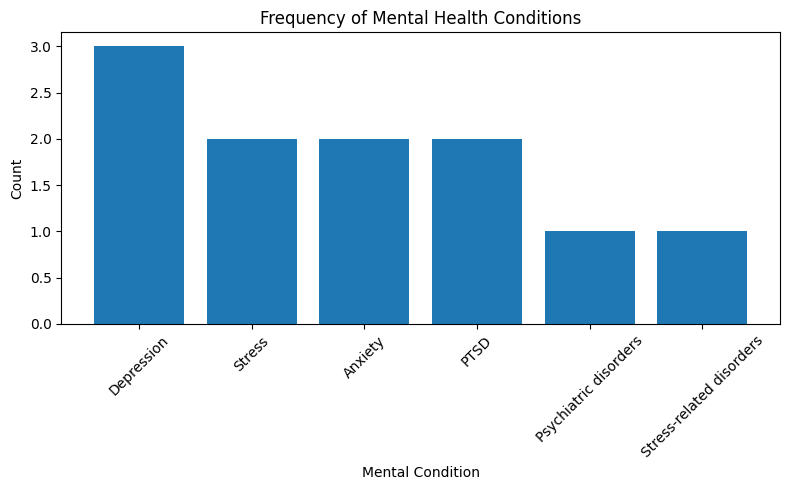

In [59]:
plt.figure(figsize=(8, 5))
plt.bar(condition_df["mental_condition"], condition_df["count"])
plt.title("Frequency of Mental Health Conditions")
plt.xlabel("Mental Condition")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [60]:
gene_counter = Counter()

for value in df["genes"]:
    items = [x.strip() for x in str(value).split(";") if x.strip()]
    gene_counter.update(items)

gene_df = pd.DataFrame(gene_counter.items(), columns=["gene", "count"])
gene_df = gene_df.sort_values("count", ascending=False).reset_index(drop=True)
gene_df

,gene,count
0,FKBP5,3
1,PPM1F,1
2,BDNF,1
3,MAN2C1,1
4,Genome-wide,1


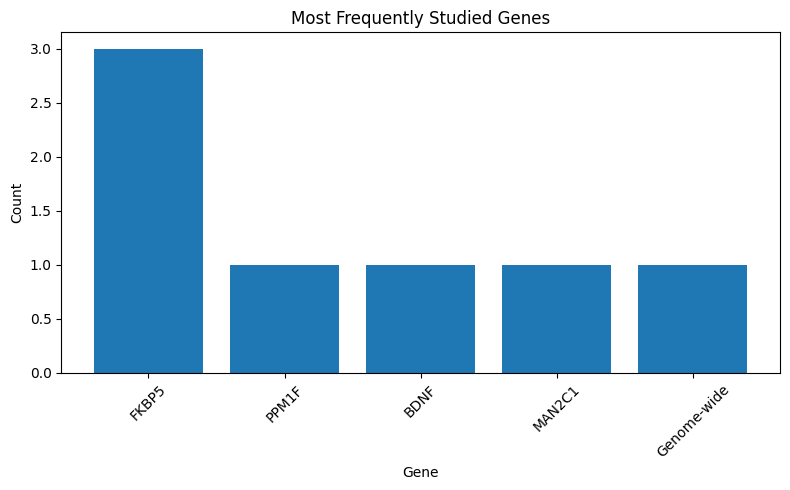

In [61]:
plt.figure(figsize=(8, 5))
plt.bar(gene_df["gene"], gene_df["count"])
plt.title("Most Frequently Studied Genes")
plt.xlabel("Gene")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [62]:
mechanism_counter = Counter()

for value in df["mechanism"]:
    items = [x.strip() for x in str(value).split(";") if x.strip()]
    mechanism_counter.update(items)

mechanism_df = pd.DataFrame(mechanism_counter.items(), columns=["mechanism", "count"])
mechanism_df = mechanism_df.sort_values("count", ascending=False).reset_index(drop=True)
mechanism_df

,mechanism,count
0,DNA methylation,5
1,Epigenetics,4
2,Gene expression,2
3,Stress response,2
4,Gene regulation,1


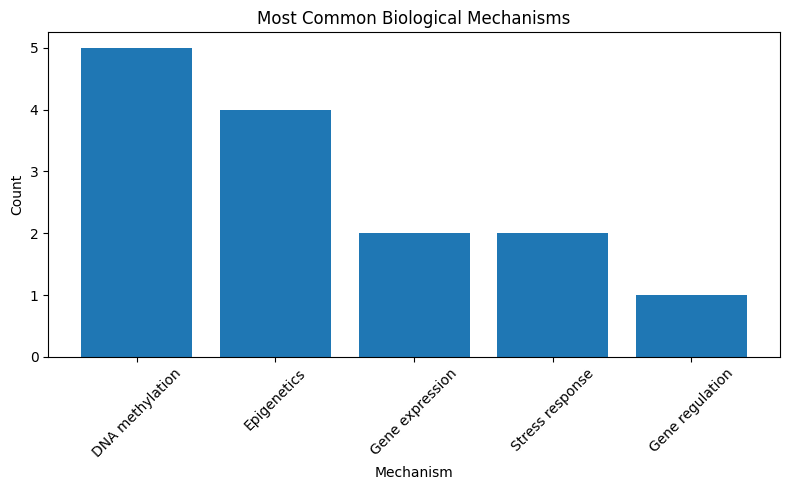

In [63]:
plt.figure(figsize=(8, 5))
plt.bar(mechanism_df["mechanism"], mechanism_df["count"])
plt.title("Most Common Biological Mechanisms")
plt.xlabel("Mechanism")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [64]:
country_counts = (
    df["country"]
    .replace("", np.nan)
    .dropna()
    .value_counts()
)

country_counts

C:\Users\Hadis\AppData\Local\Temp\ipykernel_3388\964244517.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace("", np.nan)


Series([], Name: count, dtype: int64)

In [65]:
if len(country_counts) > 0:
    plt.figure(figsize=(8, 5))
    country_counts.plot(kind="bar")
    plt.title("Papers by Country")
    plt.xlabel("Country")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
else:
    print("Country data not filled yet.")

Country data not filled yet.


In [66]:
institution_counts = (
    df["institution"]
    .replace("", np.nan)
    .dropna()
    .value_counts()
    .head(10)
)

institution_counts

C:\Users\Hadis\AppData\Local\Temp\ipykernel_3388\614319236.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace("", np.nan)


Series([], Name: count, dtype: int64)

In [67]:
if len(institution_counts) > 0:
    plt.figure(figsize=(8, 5))
    institution_counts.plot(kind="bar")
    plt.title("Top Institutions")
    plt.xlabel("Institution")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
else:
    print("Institution data not filled yet.")

Institution data not filled yet.


In [68]:
rows = []

for _, row in df.iterrows():
    conditions = [x.strip() for x in str(row["mental_condition"]).split(";") if x.strip()]
    genes = [x.strip() for x in str(row["genes"]).split(";") if x.strip()]
    
    for condition in conditions:
        for gene in genes:
            rows.append({"mental_condition": condition, "gene": gene})

gene_condition_df = pd.DataFrame(rows)
gene_condition_df.head()

,mental_condition,gene
0,Stress,PPM1F
1,Anxiety,PPM1F
2,Depression,PPM1F
3,Depression,FKBP5
4,Stress,FKBP5


In [69]:
gene_condition_table = pd.crosstab(
    gene_condition_df["gene"],
    gene_condition_df["mental_condition"]
)

gene_condition_table

mental_condition,Anxiety,Depression,PTSD,Psychiatric disorders,Stress,Stress-related disorders
gene,,,,,,
BDNF,0,0,1,0,0,0
FKBP5,0,1,0,1,1,1
Genome-wide,1,1,0,0,0,0
MAN2C1,0,0,1,0,0,0
PPM1F,1,1,0,0,1,0


In [70]:
rows = []

for _, row in df.iterrows():
    conditions = [x.strip() for x in str(row["mental_condition"]).split(";") if x.strip()]
    mechanisms = [x.strip() for x in str(row["mechanism"]).split(";") if x.strip()]
    
    for condition in conditions:
        for mechanism in mechanisms:
            rows.append({"mental_condition": condition, "mechanism": mechanism})

condition_mechanism_df = pd.DataFrame(rows)

condition_mechanism_table = pd.crosstab(
    condition_mechanism_df["mental_condition"],
    condition_mechanism_df["mechanism"]
)

condition_mechanism_table

mechanism,DNA methylation,Epigenetics,Gene expression,Gene regulation,Stress response
mental_condition,,,,,
Anxiety,1,1,1,0,0
Depression,2,2,1,0,0
PTSD,2,1,1,0,0
Psychiatric disorders,0,0,0,1,1
Stress,0,0,1,1,1
Stress-related disorders,1,1,0,0,1


In [71]:
all_text = " ".join(df["abstract"].fillna("").astype(str)).lower()

tokens = re.findall(r"\b[a-zA-Z\-]+\b", all_text)

stopwords = {
    "the", "and", "of", "to", "in", "a", "for", "with", "on", "is", "that",
    "by", "as", "an", "are", "was", "were", "be", "this", "from", "or", "at",
    "we", "it", "these", "their", "our", "can", "may", "has", "have", "had",
    "than", "but", "not", "also", "such", "into", "between", "among", "during",
    "more", "most", "both", "one", "two", "three", "using", "used", "use"
}

filtered_tokens = [t for t in tokens if t not in stopwords and len(t) > 2]
word_counts = Counter(filtered_tokens)

top_words_df = pd.DataFrame(word_counts.most_common(30), columns=["word", "count"])
top_words_df

,word,count
0,depression,22
1,methylation,17
2,stress,14
3,anxiety,13
4,ptsd,12
5,gene,10
6,genetic,9
7,epigenetic,9
8,genes,9
9,levels,8


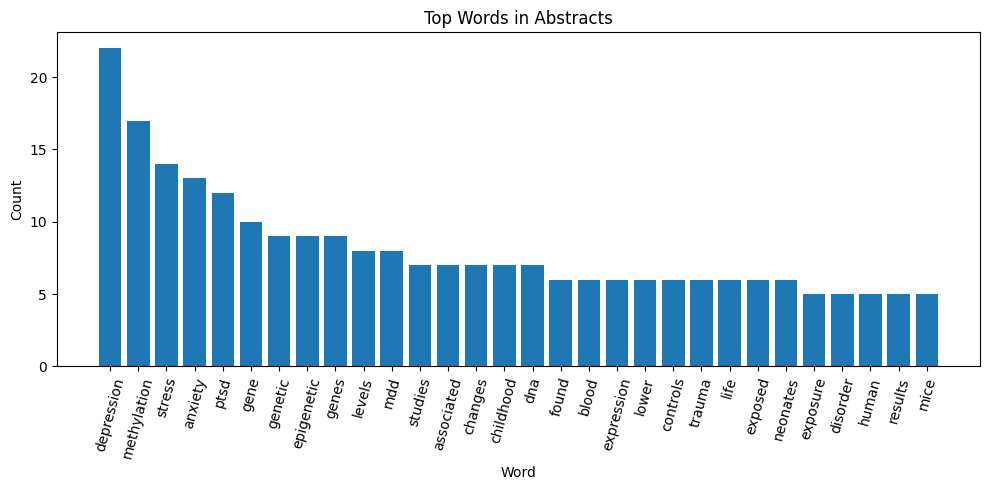

In [72]:
plt.figure(figsize=(10, 5))
plt.bar(top_words_df["word"], top_words_df["count"])
plt.title("Top Words in Abstracts")
plt.xlabel("Word")
plt.ylabel("Count")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

In [73]:
keywords = [
    "stress", "depression", "anxiety", "ptsd",
    "methylation", "epigenetic", "epigenetics",
    "expression", "gene", "genes", "biomarker",
    "cortisol", "neuroplasticity", "trauma", "brain",
    "inflammation", "serotonin", "glucocorticoid"
]

keyword_freq = {}

all_text = " ".join(df["abstract"].fillna("").astype(str)).lower()

for kw in keywords:
    keyword_freq[kw] = len(re.findall(rf"\b{re.escape(kw)}\b", all_text))

keyword_df = pd.DataFrame(list(keyword_freq.items()), columns=["keyword", "count"])
keyword_df = keyword_df.sort_values("count", ascending=False).reset_index(drop=True)
keyword_df

,keyword,count
0,depression,23
1,methylation,17
2,stress,15
3,anxiety,14
4,ptsd,13
5,gene,10
6,epigenetic,9
7,genes,9
8,trauma,9
9,expression,6


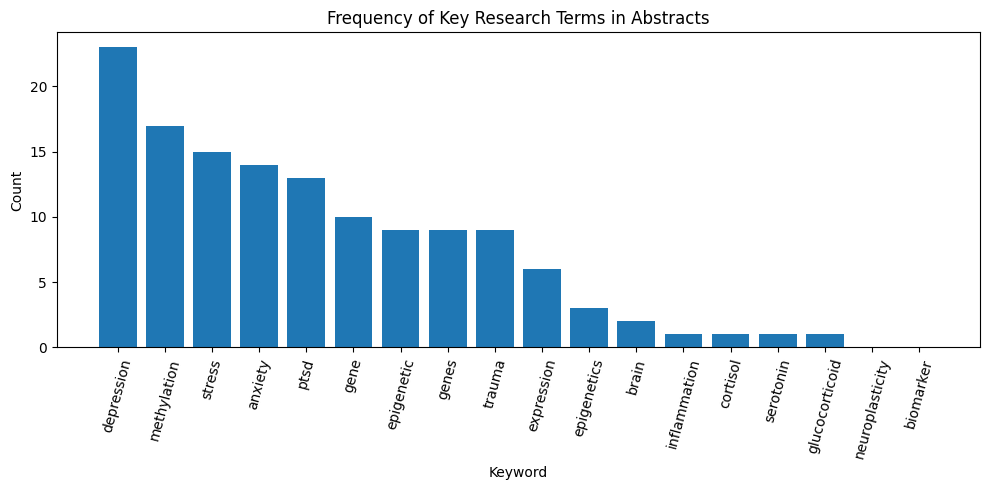

In [74]:
plt.figure(figsize=(10, 5))
plt.bar(keyword_df["keyword"], keyword_df["count"])
plt.title("Frequency of Key Research Terms in Abstracts")
plt.xlabel("Keyword")
plt.ylabel("Count")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

In [75]:
def get_keyword_counts_for_condition(dataframe, condition_name, keywords):
    subset = dataframe[dataframe["mental_condition"].str.contains(condition_name, case=False, na=False)]
    text = " ".join(subset["abstract"].fillna("").astype(str)).lower()
    
    counts = {}
    for kw in keywords:
        counts[kw] = len(re.findall(rf"\b{re.escape(kw)}\b", text))
    
    return pd.DataFrame(list(counts.items()), columns=["keyword", "count"]).sort_values("count", ascending=False)

depression_keywords = get_keyword_counts_for_condition(df, "Depression", keywords)
ptsd_keywords = get_keyword_counts_for_condition(df, "PTSD", keywords)

print("Depression-related abstracts:")
display(depression_keywords)

print("\nPTSD-related abstracts:")
display(ptsd_keywords)

Depression-related abstracts:


,keyword,count
1,depression,13
2,anxiety,10
0,stress,6
3,ptsd,5
4,methylation,5
5,epigenetic,2
8,gene,2
7,expression,1
9,genes,1
13,trauma,1



PTSD-related abstracts:


,keyword,count
9,genes,8
3,ptsd,8
4,methylation,7
13,trauma,6
8,gene,6
5,epigenetic,6
7,expression,5
1,depression,4
2,anxiety,4
0,stress,2


In [76]:
def subset_by_country(dataframe, country_name):
    return dataframe[dataframe["country"].str.contains(country_name, case=False, na=False)]

country_name = "USA"  # change as needed
usa_df = subset_by_country(df, country_name)
usa_df[["paper_id", "title", "country", "genes", "mechanism"]]

,paper_id,title,country,genes,mechanism


In [77]:
summary = {
    "number_of_papers": len(df),
    "year_range_min": int(df["year"].min()) if df["year"].notna().any() else None,
    "year_range_max": int(df["year"].max()) if df["year"].notna().any() else None,
    "most_common_gene": gene_df.iloc[0]["gene"] if len(gene_df) > 0 else None,
    "most_common_mechanism": mechanism_df.iloc[0]["mechanism"] if len(mechanism_df) > 0 else None,
    "most_common_condition": condition_df.iloc[0]["mental_condition"] if len(condition_df) > 0 else None,
}

summary

{'number_of_papers': 7,
 'year_range_min': 2011,
 'year_range_max': 2025,
 'most_common_gene': 'FKBP5',
 'most_common_mechanism': 'DNA methylation',
 'most_common_condition': 'Depression'}

In [78]:
gene_df.to_csv("psygene_gene_counts.csv", index=False)
mechanism_df.to_csv("psygene_mechanism_counts.csv", index=False)
condition_df.to_csv("psygene_condition_counts.csv", index=False)
gene_condition_table.to_csv("psygene_gene_condition_table.csv")
condition_mechanism_table.to_csv("psygene_condition_mechanism_table.csv")
top_words_df.to_csv("psygene_top_words.csv", index=False)
keyword_df.to_csv("psygene_keyword_counts.csv", index=False)

print("EDA tables saved.")

EDA tables saved.


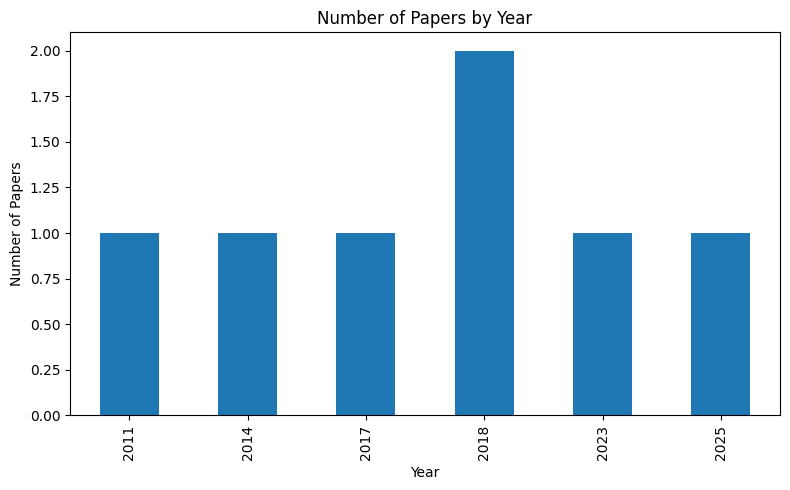

In [79]:
# Example: save one figure
plt.figure(figsize=(8, 5))
papers_per_year.plot(kind="bar")
plt.title("Number of Papers by Year")
plt.xlabel("Year")
plt.ylabel("Number of Papers")
plt.tight_layout()
plt.savefig("psygene_papers_by_year.png", dpi=300)
plt.show()